<a href="https://colab.research.google.com/github/pratyush981/Super-Image-Resolution-using-DIV2K/blob/main/ROBOFLOW_GLACIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics opencv-python-headless matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.1 MB/s eta 0:00:00


In [2]:
from google.colab import files
uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
print("Uploaded:", zip_name)


Saving glacier images data set.v2i.png-mask-semantic.zip to glacier images data set.v2i.png-mask-semantic.zip
Uploaded: glacier images data set.v2i.png-mask-semantic.zip


In [3]:
!unzip -q "$zip_name" -d /content/raw_dataset
!ls /content/raw_dataset


README.dataset.txt  README.roboflow.txt  test  train  valid


In [4]:
!find /content/raw_dataset/train -maxdepth 2 -type d
!find /content/raw_dataset/valid -maxdepth 2 -type d
!find /content/raw_dataset/test  -maxdepth 2 -type d


/content/raw_dataset/train
/content/raw_dataset/valid
/content/raw_dataset/test


In [5]:
!ls -la /content/raw_dataset
!find /content/raw_dataset -maxdepth 4 -type d | head -n 200


total 204
drwxr-xr-x 5 root root   4096 Jan  5 09:09 .
drwxr-xr-x 1 root root   4096 Jan  5 09:09 ..
-rw-r--r-- 1 root root    158 Nov 13  2024 README.dataset.txt
-rw-r--r-- 1 root root   1382 Nov 13  2024 README.roboflow.txt
drwxr-xr-x 2 root root  12288 Nov 13  2024 test
drwxr-xr-x 2 root root 159744 Nov 13  2024 train
drwxr-xr-x 2 root root  20480 Nov 13  2024 valid
/content/raw_dataset
/content/raw_dataset/test
/content/raw_dataset/train
/content/raw_dataset/valid


In [6]:
import os, glob
import cv2
import numpy as np
from tqdm import tqdm

RAW = "/content/raw_dataset"
OUT = "/content/yolo_dataset"
splits = ["train", "valid", "test"]

os.makedirs(OUT, exist_ok=True)

IMG_EXTS = (".jpg", ".jpeg", ".png")

def is_image_file(name: str) -> bool:
    return name.lower().endswith(IMG_EXTS)

def list_split_files(split_dir):
    files = [f for f in os.listdir(split_dir) if is_image_file(f)]
    # Most Roboflow png-mask exports: masks are PNG and contain "mask"
    masks = [f for f in files if ("mask" in f.lower()) and f.lower().endswith(".png")]
    imgs  = [f for f in files if f not in masks]
    return imgs, masks

def find_mask_for_image(img_name, mask_files):
    base, _ = os.path.splitext(img_name)

    # Common Roboflow patterns
    candidates = [
        f"{base}_mask.png",
        f"{base}-mask.png",
        f"{base}__mask.png",
        f"{base}.mask.png",
    ]
    for c in candidates:
        if c in mask_files:
            return c

    # Fallback: any mask file that contains the base name
    hits = [m for m in mask_files if base in m]
    if len(hits) == 1:
        return hits[0]

    # If multiple, prefer the shortest (often exact match + suffix)
    if len(hits) > 1:
        hits.sort(key=len)
        return hits[0]

    return None

def mask_to_polygons(mask_gray, min_area=50):
    """
    Convert a binary mask (0/255) to a list of polygons (each polygon is Nx2 array).
    """
    # Ensure binary
    _, bin_mask = cv2.threshold(mask_gray, 127, 255, cv2.THRESH_BINARY)

    contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        # Simplify slightly to reduce points (optional; keeps shape)
        eps = 0.002 * cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, eps, True)

        cnt = cnt.squeeze()
        if cnt.ndim != 2 or cnt.shape[0] < 3:
            continue

        polys.append(cnt)

    return polys

def convert_split(split):
    split_dir = os.path.join(RAW, split)
    imgs, masks = list_split_files(split_dir)

    out_img_dir = os.path.join(OUT, split, "images")
    out_lbl_dir = os.path.join(OUT, split, "labels")
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(out_lbl_dir, exist_ok=True)

    missing_masks = 0
    empty_masks = 0

    for img_name in tqdm(imgs, desc=f"Converting {split}"):
        mask_name = find_mask_for_image(img_name, masks)
        if mask_name is None:
            missing_masks += 1
            continue

        img_path = os.path.join(split_dir, img_name)
        mask_path = os.path.join(split_dir, mask_name)

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            missing_masks += 1
            continue

        # Copy image to YOLO folder
        cv2.imwrite(os.path.join(out_img_dir, img_name), img)

        # Convert mask -> polygons
        polys = mask_to_polygons(mask, min_area=80)

        label_path = os.path.join(out_lbl_dir, os.path.splitext(img_name)[0] + ".txt")
        with open(label_path, "w") as f:
            if len(polys) == 0:
                # valid empty label file for no objects
                empty_masks += 1
                pass
            else:
                for poly in polys:
                    # normalize coordinates to [0,1]
                    coords = []
                    for x, y in poly:
                        coords.append(x / w)
                        coords.append(y / h)
                    # class id = 0 (glacier)
                    f.write("0 " + " ".join(map(str, coords)) + "\n")

    print(f"[{split}] images: {len(imgs)} | masks: {len(masks)} | missing masks: {missing_masks} | empty masks: {empty_masks}")

for s in splits:
    convert_split(s)

print("Done. YOLO dataset written to:", OUT)


Converting train: 100%|██████████| 795/795 [00:02<00:00, 277.23it/s]


[train] images: 795 | masks: 795 | missing masks: 0 | empty masks: 795


Converting valid: 100%|██████████| 75/75 [00:00<00:00, 633.45it/s]


[valid] images: 75 | masks: 75 | missing masks: 0 | empty masks: 75


Converting test: 100%|██████████| 38/38 [00:00<00:00, 760.19it/s]

[test] images: 38 | masks: 38 | missing masks: 0 | empty masks: 38
Done. YOLO dataset written to: /content/yolo_dataset


In [7]:
!find /content/yolo_dataset -maxdepth 3 -type d
!ls -la /content/yolo_dataset/train/images | head
!ls -la /content/yolo_dataset/train/labels | head


/content/yolo_dataset
/content/yolo_dataset/test
/content/yolo_dataset/test/images
/content/yolo_dataset/test/labels
/content/yolo_dataset/train
/content/yolo_dataset/train/images
/content/yolo_dataset/train/labels
/content/yolo_dataset/valid
/content/yolo_dataset/valid/images
/content/yolo_dataset/valid/labels
total 22580
drwxr-xr-x 2 root root 110592 Jan  5 09:09 .
drwxr-xr-x 4 root root   4096 Jan  5 09:09 ..
-rw-r--r-- 1 root root  36278 Jan  5 09:09 image-data-100-_jpg.rf.69fd01b0b8b069c2740aee8a6fdcaf22.jpg
-rw-r--r-- 1 root root  27619 Jan  5 09:09 image-data-100-_jpg.rf.95591f889e38209fb53ce32b802124de.jpg
-rw-r--r-- 1 root root  27416 Jan  5 09:09 image-data-100-_jpg.rf.ec8fd28713489687135fb93921001f6b.jpg
-rw-r--r-- 1 root root  23922 Jan  5 09:09 image-data-101-_jpg.rf.448c8b053ebe4ce7967765a5012c14a6.jpg
-rw-r--r-- 1 root root  22183 Jan  5 09:09 image-data-101-_jpg.rf.6da02e848e1dd97fd39a2608adceef03.jpg
-rw-r--r-- 1 root root  30199 Jan  5 09:09 image-data-101-_jpg.rf.90b

In [8]:
data_yaml_text = """\
path: /content/yolo_dataset
train: train/images
val: valid/images
test: test/images

names:
  0: glacier
"""

with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write(data_yaml_text)

print(data_yaml_text)


path: /content/yolo_dataset
train: train/images
val: valid/images
test: test/images

names:
  0: glacier



Num images: 795
Num masks : 795
Sample image: image-data-100-_jpg.rf.69fd01b0b8b069c2740aee8a6fdcaf22.jpg
Matched mask: image-data-100-_jpg.rf.69fd01b0b8b069c2740aee8a6fdcaf22_mask.png
Image shape: (256, 256, 3)
Mask shape: (256, 256) dtype: uint8 min: 0 max: 5
Unique grayscale values (first 20): [0 5] count: 2
Foreground pixels: 34743


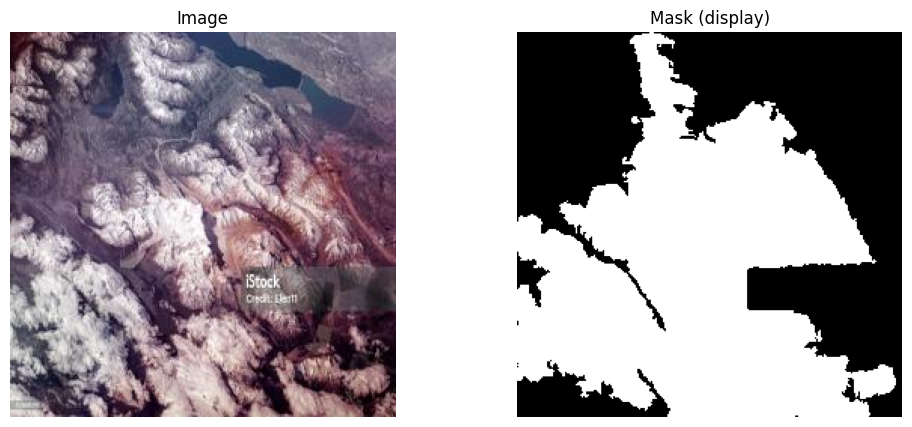

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

split_dir = "/content/raw_dataset/train"
files = sorted([f for f in os.listdir(split_dir) if f.lower().endswith((".png",".jpg",".jpeg"))])

mask_files = [f for f in files if "mask" in f.lower() and f.lower().endswith(".png")]
img_files  = [f for f in files if f not in mask_files]

print("Num images:", len(img_files))
print("Num masks :", len(mask_files))

# pick a sample image
img_name = img_files[0]
base = os.path.splitext(img_name)[0]

# find probable mask (Roboflow pattern)
cands = [base + "_mask.png", base + "-mask.png", base + "__mask.png", base + ".mask.png"]
mask_name = None
for c in cands:
    if c in mask_files:
        mask_name = c
        break

if mask_name is None:
    # fallback: any mask containing base
    hits = [m for m in mask_files if base in m]
    mask_name = hits[0] if hits else None

print("Sample image:", img_name)
print("Matched mask:", mask_name)

img = cv2.imread(os.path.join(split_dir, img_name))
mask = cv2.imread(os.path.join(split_dir, mask_name), cv2.IMREAD_UNCHANGED) if mask_name else None

print("Image shape:", img.shape if img is not None else None)

if mask is None:
    print("Mask could not be loaded / not found.")
else:
    print("Mask shape:", mask.shape, "dtype:", mask.dtype, "min:", mask.min(), "max:", mask.max())

    # For grayscale masks, print unique values (first 20)
    if len(mask.shape) == 2:
        vals = np.unique(mask)
        print("Unique grayscale values (first 20):", vals[:20], "count:", len(vals))
        fg = (mask > 0)
    elif mask.shape[2] == 4:
        alpha = mask[:,:,3]
        vals = np.unique(alpha)
        print("Alpha unique (first 20):", vals[:20], "count:", len(vals))
        fg = (alpha > 0)
    else:
        fg = np.any(mask[:,:,:3] > 0, axis=2)

    print("Foreground pixels:", int(np.count_nonzero(fg)))

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.title("Image")
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Mask (display)")
    if len(mask.shape) == 2:
        plt.imshow(mask, cmap="gray")
    else:
        plt.imshow(mask[:,:,:3])
    plt.axis("off")
    plt.show()


In [14]:
import os, shutil
import cv2
import numpy as np
from tqdm import tqdm

RAW = "/content/raw_dataset"
OUT = "/content/yolo_dataset"
splits = ["train", "valid", "test"]

# Reset output
if os.path.exists(OUT):
    shutil.rmtree(OUT)
os.makedirs(OUT, exist_ok=True)

IMG_EXTS = (".jpg", ".jpeg", ".png")

def is_img(name):
    return name.lower().endswith(IMG_EXTS)

def list_files(split_dir):
    files = [f for f in os.listdir(split_dir) if is_img(f)]
    masks = [f for f in files if "mask" in f.lower() and f.lower().endswith(".png")]
    imgs  = [f for f in files if f not in masks]
    return imgs, masks

def find_mask(img_name, masks):
    base, _ = os.path.splitext(img_name)
    candidates = [
        f"{base}_mask.png",
        f"{base}-mask.png",
        f"{base}__mask.png",
        f"{base}.mask.png",
    ]
    for c in candidates:
        if c in masks:
            return c
    hits = [m for m in masks if base in m]
    if len(hits) == 1:
        return hits[0]
    if len(hits) > 1:
        hits.sort(key=len)
        return hits[0]
    return None

def mask_to_binary(mask_gray):
    # YOUR MASK: values are 0 and 5
    # Foreground (glacier) = mask > 0
    return (mask_gray > 0).astype(np.uint8) * 255

def mask_to_polys(bin_mask, min_area=80):
    contours, _ = cv2.findContours(bin_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polys = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        eps = 0.002 * cv2.arcLength(cnt, True)
        cnt = cv2.approxPolyDP(cnt, eps, True)
        cnt = cnt.squeeze()
        if cnt.ndim != 2 or cnt.shape[0] < 3:
            continue
        polys.append(cnt)
    return polys

for split in splits:
    split_dir = os.path.join(RAW, split)
    imgs, masks = list_files(split_dir)

    out_img = os.path.join(OUT, split, "images")
    out_lbl = os.path.join(OUT, split, "labels")
    os.makedirs(out_img, exist_ok=True)
    os.makedirs(out_lbl, exist_ok=True)

    missing, empty, nonempty = 0, 0, 0

    for img_name in tqdm(imgs, desc=f"Converting {split}"):
        mask_name = find_mask(img_name, masks)
        if mask_name is None:
            missing += 1
            continue

        img_path = os.path.join(split_dir, img_name)
        mask_path = os.path.join(split_dir, mask_name)

        img = cv2.imread(img_path)
        if img is None:
            continue
        h, w = img.shape[:2]

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            missing += 1
            continue

        bin_mask = mask_to_binary(mask)
        polys = mask_to_polys(bin_mask, min_area=80)

        # copy image
        cv2.imwrite(os.path.join(out_img, img_name), img)

        label_path = os.path.join(out_lbl, os.path.splitext(img_name)[0] + ".txt")
        with open(label_path, "w") as f:
            if len(polys) == 0:
                empty += 1
            else:
                nonempty += 1
                for poly in polys:
                    coords = []
                    for x, y in poly:
                        coords.append(x / w)
                        coords.append(y / h)
                    f.write("0 " + " ".join(map(str, coords)) + "\n")

    print(f"[{split}] imgs={len(imgs)} masks={len(masks)} missing={missing} empty={empty} nonempty={nonempty}")

print("Conversion complete:", OUT)


Converting train: 100%|██████████| 795/795 [00:05<00:00, 134.85it/s]


[train] imgs=795 masks=795 missing=0 empty=21 nonempty=774


Converting valid: 100%|██████████| 75/75 [00:00<00:00, 487.78it/s]


[valid] imgs=75 masks=75 missing=0 empty=2 nonempty=73


Converting test: 100%|██████████| 38/38 [00:00<00:00, 520.71it/s]

[test] imgs=38 masks=38 missing=0 empty=1 nonempty=37
Conversion complete: /content/yolo_dataset


In [15]:
!wc -c /content/yolo_dataset/train/labels/*.txt | head


   1783 /content/yolo_dataset/train/labels/image-data-100-_jpg.rf.69fd01b0b8b069c2740aee8a6fdcaf22.txt
   1589 /content/yolo_dataset/train/labels/image-data-100-_jpg.rf.95591f889e38209fb53ce32b802124de.txt
   1609 /content/yolo_dataset/train/labels/image-data-100-_jpg.rf.ec8fd28713489687135fb93921001f6b.txt
   1712 /content/yolo_dataset/train/labels/image-data-101-_jpg.rf.448c8b053ebe4ce7967765a5012c14a6.txt
   1822 /content/yolo_dataset/train/labels/image-data-101-_jpg.rf.6da02e848e1dd97fd39a2608adceef03.txt
   2197 /content/yolo_dataset/train/labels/image-data-101-_jpg.rf.90ba1a946d51cbef5c58d5df7097a9a4.txt
   6518 /content/yolo_dataset/train/labels/image-data-102-_jpg.rf.304f999ba529a3118058bf76cc67bd67.txt
   7093 /content/yolo_dataset/train/labels/image-data-102-_jpg.rf.69b99b4637c8e7c9422fef52091feece.txt
   6394 /content/yolo_dataset/train/labels/image-data-102-_jpg.rf.9d29f28591710cde15e94c5d48a7f3ac.txt
   2012 /content/yolo_dataset/train/labels/image-data-103-_jpg.rf.4b40be6

In [16]:
with open("/content/yolo_dataset/data.yaml", "w") as f:
    f.write("""\
path: /content/yolo_dataset
train: train/images
val: valid/images
test: test/images
names:
  0: glacier
""")
print("data.yaml created")


data.yaml created


In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n-seg.pt")

model.train(
    data="/content/yolo_dataset/data.yaml",
    epochs=15,
    imgsz=640,
    batch=8,
    device=0
)


Ultralytics 8.3.248 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, po

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7afd35e4b3b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041, 

In [19]:
test_image = "/content/yolo_dataset/test/images/" + \
             os.listdir("/content/yolo_dataset/test/images")[0]


Testing on: /content/raw_dataset/test/image-data-110-_jpg.rf.e5dfb648aa22fd1b1099028f4f60ed6b.jpg

image 1/1 /content/raw_dataset/test/image-data-110-_jpg.rf.e5dfb648aa22fd1b1099028f4f60ed6b.jpg: 640x640 (no detections), 9.4ms
Speed: 2.1ms preprocess, 9.4ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 640)


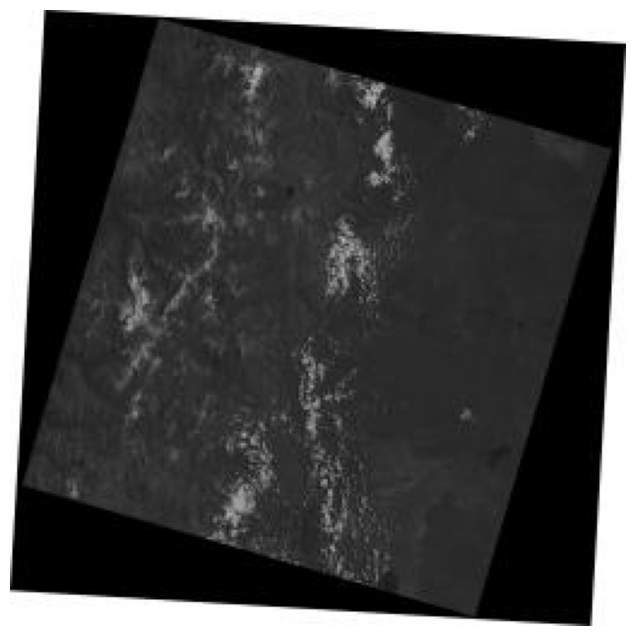

In [26]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# -------------------------------
# Model path (TRAINED model)
# -------------------------------
model_path = "/content/yolo11n.pt"

# -------------------------------
# Load model
# -------------------------------
model = YOLO(model_path)

# -------------------------------
# Pick a test image
# -------------------------------
test_image = "/content/raw_dataset/test/image-data-110-_jpg.rf.e5dfb648aa22fd1b1099028f4f60ed6b.jpg"

print("Testing on:", test_image)

# -------------------------------
# Run inference
# -------------------------------
pred = model.predict(
    source=test_image,
    conf=0.25,
    imgsz=640
)[0]

# -------------------------------
# Visualize
# -------------------------------
img = pred.plot()  # BGR
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")
plt.show()
